# ================================================
# FILE 4: PERANCANGAN & PELATIHAN MODEL BI-LSTM
# ================================================
# Penelitian : Perbandingan LSTM vs Bi-LSTM untuk Analisis Sentimen MBG
# Model      : Bidirectional Long Short-Term Memory (Bi-LSTM)
# Pengujian  : 4 Skenario (variasi epoch & units)
# Platform   : Google Colab
# ================================================

# BAGIAN 0 — SETUP & INSTALASI

In [1]:
# ============================================================
# BAGIAN 0 — SETUP & INSTALASI
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# WAJIB IDENTIK dengan file LSTM
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("=" * 70)
print("SETUP & LIBRARY BERHASIL DIMUAT")
print("=" * 70)
print(f"TensorFlow version : {tf.__version__}")

from google.colab import drive
drive.mount('/content/drive')

# Path — IDENTIK dengan file LSTM
BASE_DIR  = '/content/drive/MyDrive/skripsi_mbg'
EMBED_DIR = f'{BASE_DIR}/data/embeddings'
BILSTM_DIR  = f'{BASE_DIR}/results_bilstm'

os.makedirs(BILSTM_DIR, exist_ok=True)
os.makedirs(f'{BILSTM_DIR}/plots', exist_ok=True)
os.makedirs(f'{BILSTM_DIR}/models', exist_ok=True)

print(f"\n✅ Direktori output : {BILSTM_DIR}")


SETUP & LIBRARY BERHASIL DIMUAT
TensorFlow version : 2.20.0
Mounted at /content/drive

✅ Direktori output : /content/drive/MyDrive/skripsi_mbg/results_bilstm


# BAGIAN 1 — LOAD DATA HASIL EMBEDDING

In [2]:
# ============================================================
# BAGIAN 1 — LOAD DATA HASIL EMBEDDING
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 1: LOAD DATA (IDENTIK DENGAN FILE LSTM)")
print("=" * 70)

# Load X dan y
X = np.load(f'{EMBED_DIR}/X_padded_sequences.npy')
y = np.load(f'{EMBED_DIR}/y_onehot_labels.npy')

# Load label encoder
with open(f'{EMBED_DIR}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load tokenizer
with open(f'{EMBED_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# Load metadata
with open(f'{EMBED_DIR}/embedding_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"✅ Data berhasil dimuat!")
print(f"\nDimensi Data:")
print(f"  X shape : {X.shape} (jumlah_tweet × MAX_LENGTH)")
print(f"  y shape : {y.shape} (jumlah_tweet × num_classes)")
print(f"\nInformasi Label:")
print(f"  Kelas   : {le.classes_.tolist()}")

y_classes = np.argmax(y, axis=1)
unique, counts = np.unique(y_classes, return_counts=True)

print(f"\nDistribusi Kelas:")
for cls_idx, cnt in zip(unique, counts):
    print(f"  {le.classes_[cls_idx]:<10} ({cls_idx}): {cnt:>4} samples ({cnt/len(y)*100:.1f}%)")



BAGIAN 1: LOAD DATA (IDENTIK DENGAN FILE LSTM)
✅ Data berhasil dimuat!

Dimensi Data:
  X shape : (2245, 50) (jumlah_tweet × MAX_LENGTH)
  y shape : (2245, 3) (jumlah_tweet × num_classes)

Informasi Label:
  Kelas   : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

Distribusi Kelas:
  NEGATIVE   (0):  721 samples (32.1%)
  NEUTRAL    (1):  168 samples (7.5%)
  POSITIVE   (2): 1356 samples (60.4%)


# BAGIAN 2 — SPLIT DATA TRAIN & TEST

In [3]:
# ============================================================
# BAGIAN 2 — SPLIT DATA TRAIN & TEST
# ============================================================
# WAJIB IDENTIK dengan file LSTM
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y_classes,
    random_state = RANDOM_STATE
)

print(f"✅ Pembagian data berhasil!")
print(f"\nUkuran Data:")
print(f"  Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Split validation dari train set — IDENTIK dengan LSTM
y_train_classes = np.argmax(y_train, axis=1)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.2,
    stratify     = y_train_classes,
    random_state = RANDOM_STATE
)

print(f"\nSplit tambahan untuk validation:")
print(f"  X_tr (train aktual) : {X_tr.shape[0]} samples")
print(f"  X_val (validation)  : {X_val.shape[0]} samples")

print(f"\nDistribusi kelas di Test set:")
y_test_classes = np.argmax(y_test, axis=1)
for cls_idx in unique:
    cnt = np.sum(y_test_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt:>3} ({cnt/len(y_test)*100:.1f}%)")

print(f"\n⚠️ Pastikan angka di atas SAMA dengan file LSTM!")


✅ Pembagian data berhasil!

Ukuran Data:
  Train : 1796 samples (80%)
  Test  : 449 samples (20%)

Split tambahan untuk validation:
  X_tr (train aktual) : 1436 samples
  X_val (validation)  : 360 samples

Distribusi kelas di Test set:
  NEGATIVE  : 144 (32.1%)
  NEUTRAL   :  34 (7.6%)
  POSITIVE  : 271 (60.4%)

⚠️ Pastikan angka di atas SAMA dengan file LSTM!


## BAGIAN 2B — OVERSAMPLE KELAS NEUTRAL

In [4]:
# ============================================================
# BAGIAN 2B — OVERSAMPLE TRAIN & PERBAIKI VAL SET
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 2B: OVERSAMPLE TRAIN DAN PERBAIKI VAL SET")
print("=" * 70)

y_tr_classes  = np.argmax(y_tr, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# --- Cek distribusi sebelum ---
print(f"Distribusi TRAIN sebelum oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_tr_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\nDistribusi VAL sebelum oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_val_classes == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

# --- Oversample TRAIN ---
np.random.seed(RANDOM_STATE)

idx_neg_tr = np.where(y_tr_classes == 0)[0]
idx_neu_tr = np.where(y_tr_classes == 1)[0]
idx_pos_tr = np.where(y_tr_classes == 2)[0]

# Target: NEUTRAL naik ke 350, yang lain tetap
idx_neu_tr_over = np.random.choice(idx_neu_tr, size=350, replace=True)
all_idx_tr = np.concatenate([idx_neg_tr, idx_neu_tr_over, idx_pos_tr])
np.random.shuffle(all_idx_tr)

X_tr_resampled = X_tr[all_idx_tr]
y_tr_resampled = y_tr[all_idx_tr]

# --- Oversample VAL (lebih ringan, hanya duplikasi) ---
idx_neg_val = np.where(y_val_classes == 0)[0]
idx_neu_val = np.where(y_val_classes == 1)[0]
idx_pos_val = np.where(y_val_classes == 2)[0]

# Target: NEUTRAL val naik ke 60
idx_neu_val_over = np.random.choice(idx_neu_val, size=60, replace=True)
all_idx_val = np.concatenate([idx_neg_val, idx_neu_val_over, idx_pos_val])
np.random.shuffle(all_idx_val)

X_val_resampled = X_val[all_idx_val]
y_val_resampled = y_val[all_idx_val]

# --- Cetak hasil ---
y_tr_res_cls  = np.argmax(y_tr_resampled, axis=1)
y_val_res_cls = np.argmax(y_val_resampled, axis=1)

print(f"\nDistribusi TRAIN setelah oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_tr_res_cls == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\nDistribusi VAL setelah oversample:")
for cls_idx in range(3):
    cnt = np.sum(y_val_res_cls == cls_idx)
    print(f"  {le.classes_[cls_idx]:<10}: {cnt} samples")

print(f"\n✅ X_tr_resampled  : {X_tr_resampled.shape}")
print(f"✅ y_tr_resampled  : {y_tr_resampled.shape}")
print(f"✅ X_val_resampled : {X_val_resampled.shape}")
print(f"✅ y_val_resampled : {y_val_resampled.shape}")
print(f"\n⚠️  Test set TIDAK disentuh — evaluasi tetap pada data asli")



BAGIAN 2B: OVERSAMPLE TRAIN DAN PERBAIKI VAL SET
Distribusi TRAIN sebelum oversample:
  NEGATIVE  : 461 samples
  NEUTRAL   : 107 samples
  POSITIVE  : 868 samples

Distribusi VAL sebelum oversample:
  NEGATIVE  : 116 samples
  NEUTRAL   : 27 samples
  POSITIVE  : 217 samples

Distribusi TRAIN setelah oversample:
  NEGATIVE  : 461 samples
  NEUTRAL   : 350 samples
  POSITIVE  : 868 samples

Distribusi VAL setelah oversample:
  NEGATIVE  : 116 samples
  NEUTRAL   : 60 samples
  POSITIVE  : 217 samples

✅ X_tr_resampled  : (1679, 50)
✅ y_tr_resampled  : (1679, 3)
✅ X_val_resampled : (393, 50)
✅ y_val_resampled : (393, 3)

⚠️  Test set TIDAK disentuh — evaluasi tetap pada data asli


# BAGIAN 3 — PARAMETER MODEL & SKENARIO

In [5]:
# ============================================================
# BAGIAN 3 — PARAMETER MODEL & SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 3: PARAMETER MODEL & SKENARIO")
print("=" * 70)

# Ambil dari metadata — IDENTIK dengan LSTM
VOCAB_SIZE    = metadata['VOCAB_SIZE']    # 7000
EMBEDDING_DIM = metadata['EMBEDDING_DIM'] # 128
MAX_LENGTH    = metadata['MAX_LENGTH']    # 50
NUM_CLASSES   = metadata['NUM_CLASSES']   # 3

# Parameter training — IDENTIK dengan LSTM
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
DROPOUT_RATE  = 0.5

# Skenario — IDENTIK dengan LSTM
SKENARIO = [
    {'id': 1, 'nama': 'Skenario 1', 'epoch': 50,  'units': 64,  'label': 'Epoch=50,  Units=64'},
    {'id': 2, 'nama': 'Skenario 2', 'epoch': 75,  'units': 64,  'label': 'Epoch=75,  Units=64'},
    {'id': 3, 'nama': 'Skenario 3', 'epoch': 100, 'units': 64,  'label': 'Epoch=100, Units=64'},
    {'id': 4, 'nama': 'Skenario 4', 'epoch': 100, 'units': 128, 'label': 'Epoch=100, Units=128'},
]

print(f"Parameter Model Bi-LSTM (dari metadata, IDENTIK dengan LSTM):")
print(f"  VOCAB_SIZE    : {VOCAB_SIZE}")
print(f"  EMBEDDING_DIM : {EMBEDDING_DIM}")
print(f"  MAX_LENGTH    : {MAX_LENGTH}")
print(f"  NUM_CLASSES   : {NUM_CLASSES}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")
print(f"  LEARNING_RATE : {LEARNING_RATE}")
print(f"  DROPOUT_RATE  : {DROPOUT_RATE}")
print(f"  RANDOM_STATE  : {RANDOM_STATE}")

print(f"\n  PERBEDAAN SATU-SATUNYA:")
print(f"  File LSTM     → layer: LSTM(units)")
print(f"  File ini      → layer: Bidirectional(LSTM(units))")

print(f"\n{'='*70}")
print(f"{'No':<5} {'Nama':<15} {'Epoch':<10} {'Units':<10} {'Keterangan'}")
print(f"{'='*70}")
for s in SKENARIO:
    print(f"  {s['id']:<5} {s['nama']:<15} "
          f"{s['epoch']:<10} {s['units']:<10} {s['label']}")
print(f"{'='*70}")



BAGIAN 3: PARAMETER MODEL & SKENARIO
Parameter Model Bi-LSTM (dari metadata, IDENTIK dengan LSTM):
  VOCAB_SIZE    : 7000
  EMBEDDING_DIM : 128
  MAX_LENGTH    : 50
  NUM_CLASSES   : 3
  BATCH_SIZE    : 32
  LEARNING_RATE : 0.001
  DROPOUT_RATE  : 0.5
  RANDOM_STATE  : 42

  PERBEDAAN SATU-SATUNYA:
  File LSTM     → layer: LSTM(units)
  File ini      → layer: Bidirectional(LSTM(units))

No    Nama            Epoch      Units      Keterangan
  1     Skenario 1      50         64         Epoch=50,  Units=64
  2     Skenario 2      75         64         Epoch=75,  Units=64
  3     Skenario 3      100        64         Epoch=100, Units=64
  4     Skenario 4      100        128        Epoch=100, Units=128


# BAGIAN 4 — FUNGSI BUILD MODEL BI-LSTM

In [6]:
# ============================================================
# BAGIAN 4 — FUNGSI BUILD MODEL BI-LSTM
# ============================================================
'''
Arsitektur Bi-LSTM untuk klasifikasi sentimen 3 kelas.

Perbedaan LSTM vs Bi-LSTM:
  LSTM    : memproses urutan SATU arah (token[0] → token[n])
  Bi-LSTM : memproses DUA arah sekaligus (forward + backward)
            output size = units × 2

Susunan layer (IDENTIK dengan LSTM yang sudah dimodifikasi):
  1. Embedding        : integer → dense vector
  2. SpatialDropout1D : regularisasi khusus sequence data
  3. Bidirectional(LSTM) : proses dua arah  ← PERBEDAAN
  4. Dropout          : regularisasi
  5. Dense (ReLU)     : hidden layer
  6. Dropout          : regularisasi
  7. Dense (Softmax)  : output 3 kelas
'''

def build_bilstm_model(vocab_size, embedding_dim, max_length,
                       lstm_units, num_classes, dropout_rate, learning_rate):
    model = Sequential(name=f'BiLSTM_{lstm_units}units')

    # Layer 1: Embedding
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim,
                        input_length=max_length, name='embedding_layer'))

    # Layer 2: Spatial Dropout
    model.add(SpatialDropout1D(rate=0.2, name='spatial_dropout'))

    # Layer 3: Bidirectional LSTM
    model.add(Bidirectional(
        LSTM(units=lstm_units,
             dropout=0.2,
             recurrent_dropout=0.1,
             return_sequences=False),
        name=f'bilstm_{lstm_units}units'
    ))

    # Layer 4: Dropout setelah Bi-LSTM
    model.add(Dropout(0.3, name='dropout_after_bilstm'))

    # Layer 5: Dense Hidden
    model.add(Dense(units=64, activation='relu', name='dense_hidden'))

    # Layer 6: Dropout setelah Dense
    model.add(Dropout(0.2, name='dropout_after_dense'))

    # Layer 7: Output
    model.add(Dense(units=num_classes, activation='softmax', name='output_layer'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# Tampilkan arsitektur contoh
print("\n" + "=" * 70)
print("BAGIAN 4: ARSITEKTUR MODEL Bi-LSTM (CONTOH SKENARIO 1)")
print("=" * 70)

sample_model = build_bilstm_model(
    VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH,
    SKENARIO[0]['units'], NUM_CLASSES,
    DROPOUT_RATE, LEARNING_RATE
)
sample_model.build(input_shape=(None, MAX_LENGTH))
sample_model.summary()

print(f"\nCatatan: Bi-LSTM output shape = (None, units×2)")
print(f"  Berbeda dengan LSTM yang outputnya (None, units)")
print(f"  units=64  → LSTM output (None, 64)  | Bi-LSTM (None, 128)")
print(f"  units=128 → LSTM output (None, 128) | Bi-LSTM (None, 256)")



BAGIAN 4: ARSITEKTUR MODEL Bi-LSTM (CONTOH SKENARIO 1)


Model: "BiLSTM_64units"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 50, 128)        │       896,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_64units (Bidirectional)  │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_after_bilstm (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_after_dense (Dropout)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,003,395 (3.83 MB)

 Trainable params: 1,003,395 (3.83 MB)

 Non-trainable params: 0 (0.00 B)


Catatan: Bi-LSTM output shape = (None, units×2)
  Berbeda dengan LSTM yang outputnya (None, units)
  units=64  → LSTM output (None, 64)  | Bi-LSTM (None, 128)
  units=128 → LSTM output (None, 128) | Bi-LSTM (None, 256)


# BAGIAN 5 — FUNGSI EVALUASI DAN VISUALISASI

In [7]:
# ============================================================
# BAGIAN 5 — FUNGSI EVALUASI DAN VISUALISASI
# ============================================================
def evaluate_model(model, X_test, y_test, le, skenario_id, skenario_nama):
    '''
    Evaluasi model Bi-LSTM secara komprehensif.
    Fungsi IDENTIK dengan file LSTM untuk konsistensi.
    '''
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_test, axis=1)

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class    = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class        = f1_score(y_true, y_pred, average=None, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(
        y_true, y_pred,
        target_names=le.classes_,
        output_dict=True
    )

    results = {
        'model'       : 'Bi-LSTM',
        'skenario_id' : skenario_id,
        'skenario'    : skenario_nama,
        'accuracy'    : round(acc, 4),
        'precision'   : round(precision, 4),
        'recall'      : round(recall, 4),
        'f1_score'    : round(f1, 4),
        'confusion_matrix'       : cm.tolist(),
        'classification_report'  : cr,
    }

    for i, cls in enumerate(le.classes_):
        results[f'precision_{cls}'] = round(precision_per_class[i], 4)
        results[f'recall_{cls}']    = round(recall_per_class[i], 4)
        results[f'f1_{cls}']        = round(f1_per_class[i], 4)

    return results, cm, y_pred, y_true


def plot_confusion_matrix(cm, le, skenario_nama, save_path):
    '''Plot confusion matrix dengan warna oranye (khas Bi-LSTM).'''
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Oranges',
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(
        f'Confusion Matrix Bi-LSTM — {skenario_nama}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_training_history(history, skenario_nama, save_path):
    '''Plot training & validation accuracy/loss per epoch.'''
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Training History Bi-LSTM — {skenario_nama}',
        fontsize=13, fontweight='bold'
    )

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs_range, history.history['accuracy'],
                 'darkorange', marker='o', label='Train Accuracy', markersize=4)
    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 'red', marker='o', label='Val Accuracy', markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title('Model Accuracy', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Loss
    axes[1].plot(epochs_range, history.history['loss'],
                 'darkorange', marker='o', label='Train Loss', markersize=4)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 'red', marker='o', label='Val Loss', markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].set_title('Model Loss', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


print("✅ Semua fungsi evaluasi dan visualisasi siap")


✅ Semua fungsi evaluasi dan visualisasi siap


# BAGIAN 6 — TRAINING & EVALUASI 4 SKENARIO


BAGIAN 6: TRAINING & EVALUASI MODEL Bi-LSTM

  SKENARIO 1: Epoch=50,  Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 1,003,395
  ✅ Bi-LSTM output size : 128 (vs LSTM: 64)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=15) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_bilstm/models/bilstm_skenario1_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 50 epoch)...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.4910 - loss: 1.0518

53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.5134 - loss: 1.0221 - val_accuracy: 0.5573 - val_loss: 0.9162
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.6718 - loss: 0.7319 - val_accuracy: 0.6285 - val_loss: 0.9801
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.8916 - loss: 0.3028 - val_accuracy: 0.6489 - val_loss: 1.0814
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9619 - loss: 0.1175 - val_accuracy: 0.6692 - val_loss: 1.1774
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.9857 - loss: 0.0559 - val_accuracy: 0.6718 - val_loss: 1.4477
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.9917 - loss: 0.0313 - val_accuracy: 0.6794 - val_loss: 1.2776
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.6743 - val_loss: 1.6331
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step - accuracy: 0.9976 - loss: 0.0104 - val_accuracy: 0.6768 

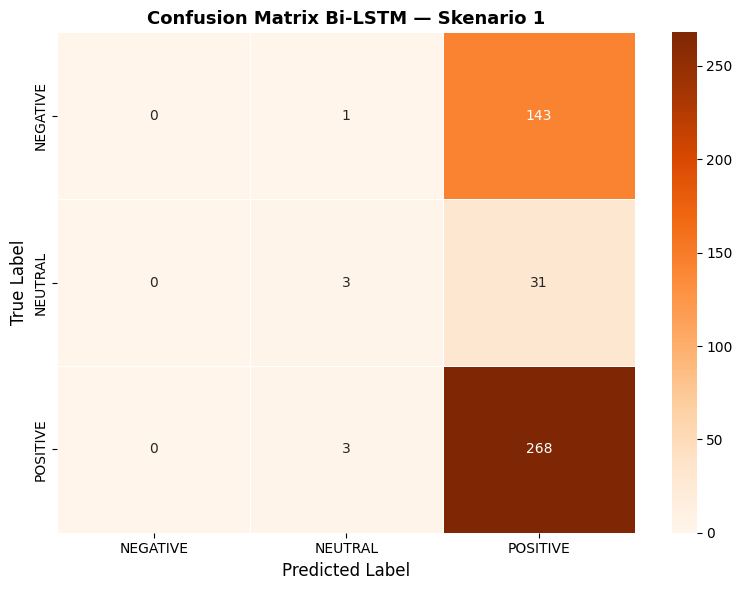

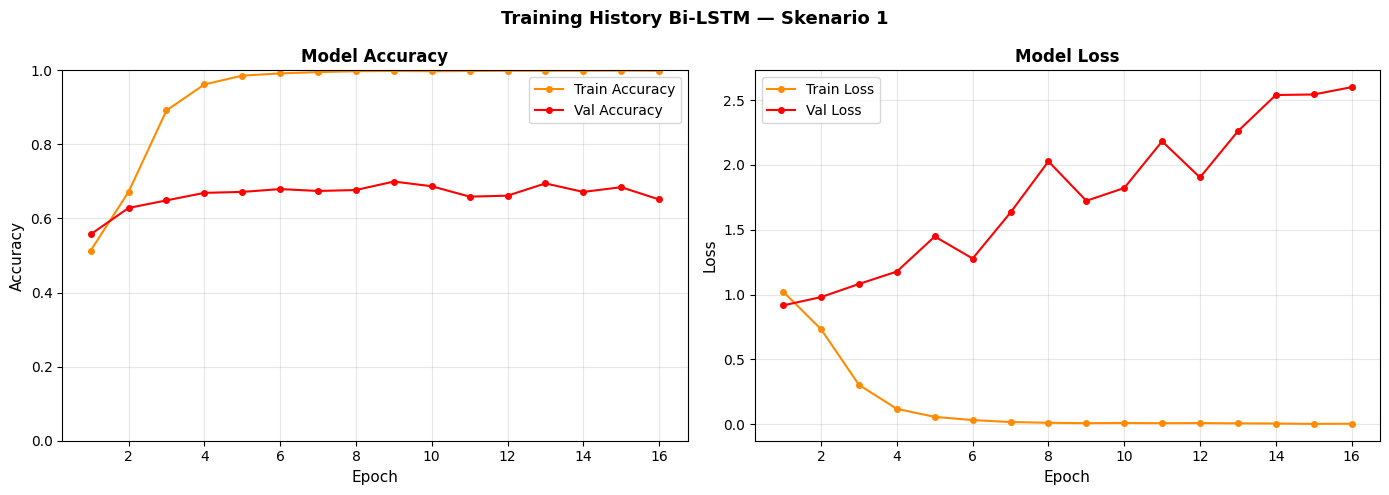


  ✅ Semua output Skenario 1 tersimpan

  SKENARIO 2: Epoch=75,  Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 1,003,395
  ✅ Bi-LSTM output size : 128 (vs LSTM: 64)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=15) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_bilstm/models/bilstm_skenario2_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 75 epoch)...
Epoch 1/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4962 - loss: 1.0518

53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.5134 - loss: 1.0232 - val_accuracy: 0.5522 - val_loss: 0.9282
Epoch 2/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.6367 - loss: 0.7942 - val_accuracy: 0.5802 - val_loss: 1.0191
Epoch 3/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.8231 - loss: 0.4438 - val_accuracy: 0.6158 - val_loss: 1.4687
Epoch 4/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.9315 - loss: 0.1992 - val_accuracy: 0.6260 - val_loss: 1.4533
Epoch 5/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.9690 - loss: 0.0918 - val_accuracy: 0.6590 - val_loss: 1.7169
Epoch 6/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.9792 - loss: 0.0606 - val_accuracy: 0.6438 - val_loss: 1.7742
Epoch 7/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.9911 - loss: 0.0319 - val_accuracy: 0.6463 - val_loss: 1.8124
Epoch 8/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.9893 - loss: 0.0364 - val_accuracy: 0.6794 - va

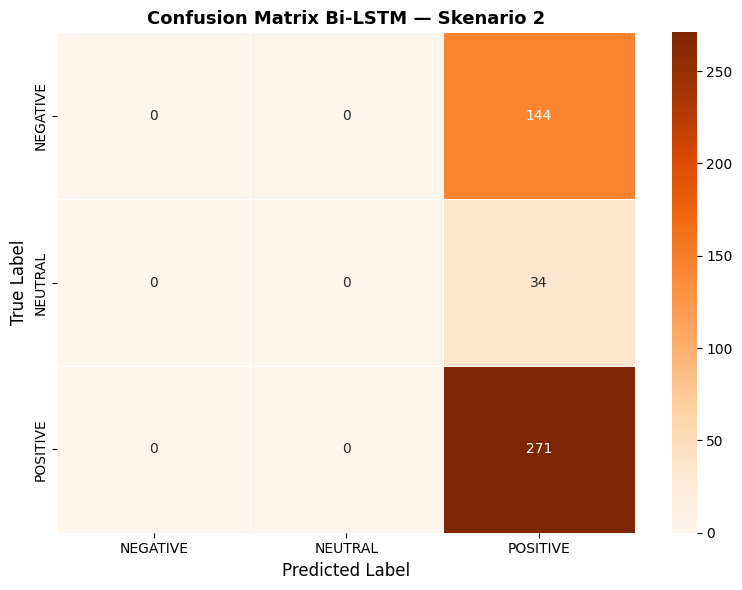

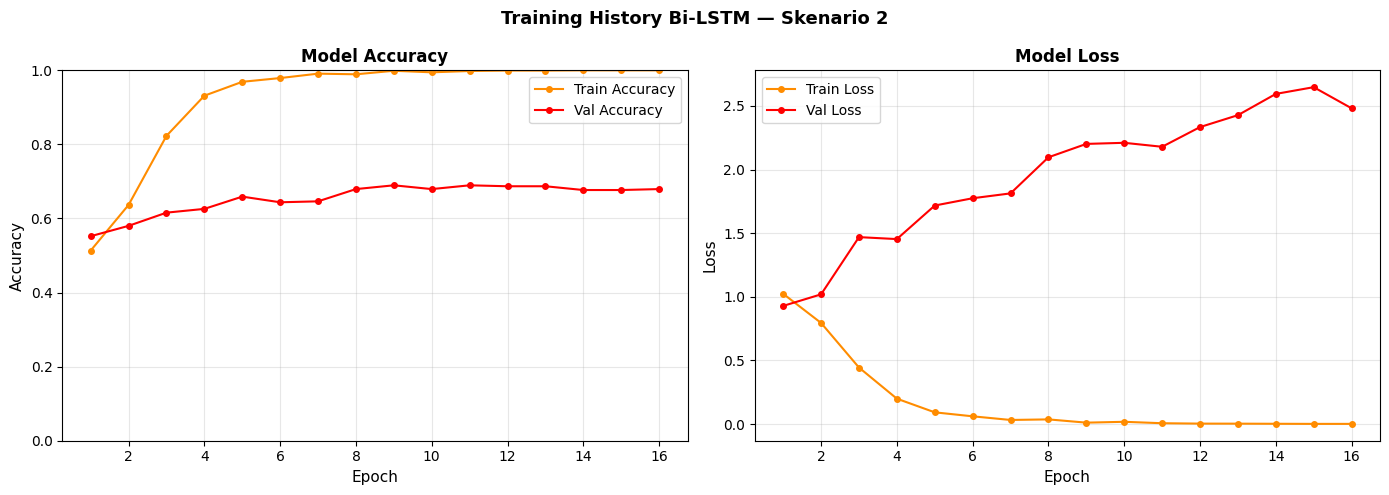


  ✅ Semua output Skenario 2 tersimpan

  SKENARIO 3: Epoch=100, Units=64

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 1,003,395
  ✅ Bi-LSTM output size : 128 (vs LSTM: 64)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=15) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_bilstm/models/bilstm_skenario3_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 100 epoch)...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4891 - loss: 1.0495

53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.5116 - loss: 1.0151 - val_accuracy: 0.5547 - val_loss: 0.9198
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.6647 - loss: 0.7304 - val_accuracy: 0.6158 - val_loss: 1.0312
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.8797 - loss: 0.3478 - val_accuracy: 0.6565 - val_loss: 1.2360
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.9535 - loss: 0.1460 - val_accuracy: 0.6667 - val_loss: 1.2498
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.9750 - loss: 0.0686 - val_accuracy: 0.6692 - val_loss: 1.5158
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.9911 - loss: 0.0354 - val_accuracy: 0.6590 - val_loss: 1.6649
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.9911 - loss: 0.0277 - val_accuracy: 0.6387 - val_loss: 1.5770
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.9964 - loss: 0.0139 - val_accuracy: 0.6

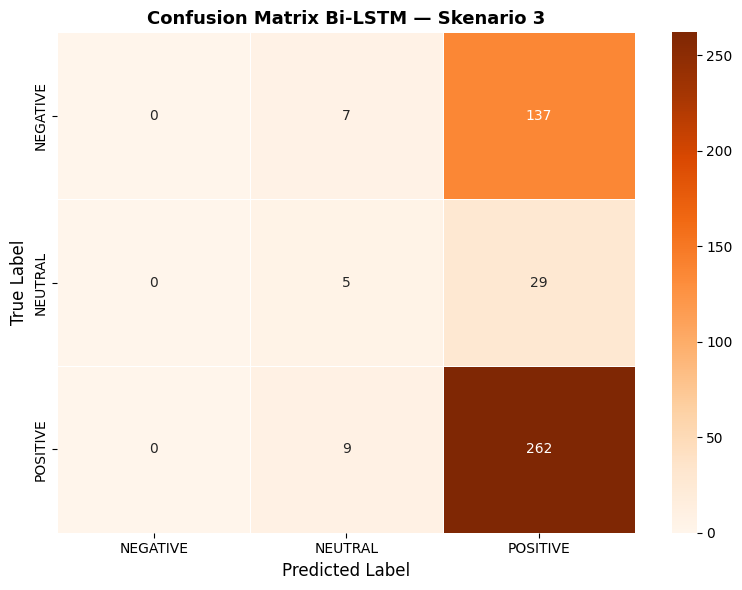

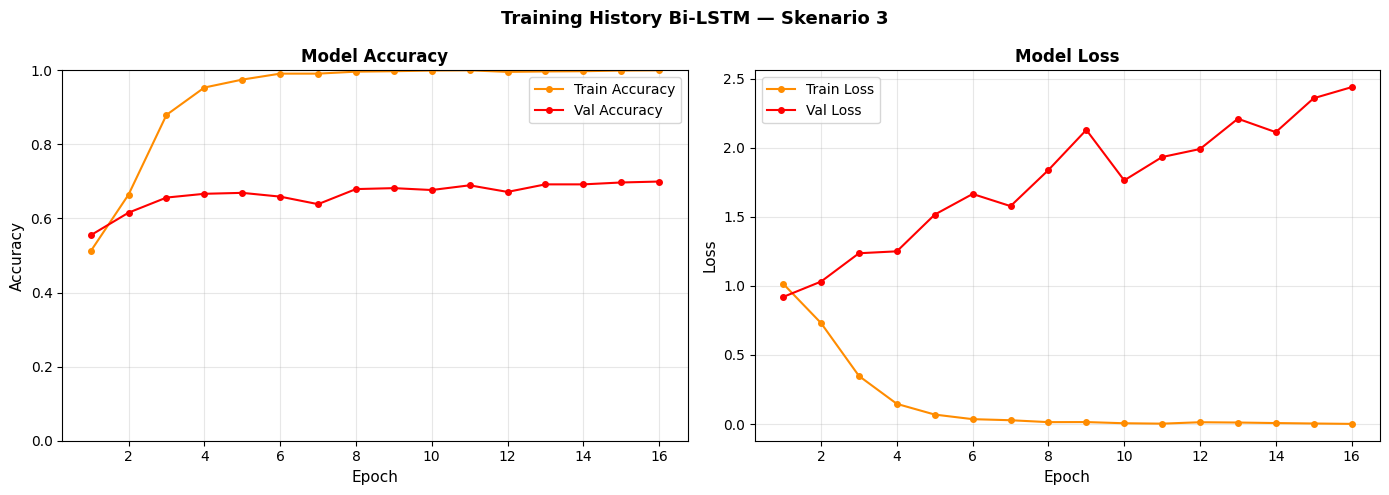


  ✅ Semua output Skenario 3 tersimpan

  SKENARIO 4: Epoch=100, Units=128

  [1/4] Membangun arsitektur model...
  ✅ Model berhasil dibangun
  ✅ Total parameters : 1,175,939
  ✅ Bi-LSTM output size : 256 (vs LSTM: 128)

  [2/4] Setup callbacks...
  ✅ EarlyStopping (patience=15) aktif
  ✅ ModelCheckpoint → /content/drive/MyDrive/skripsi_mbg/results_bilstm/models/bilstm_skenario4_best.h5

  Class weights:
    Class 0 (NEGATIVE  ): 1.0383
    Class 1 (NEUTRAL   ): 4.4735
    Class 2 (POSITIVE  ): 0.5515

  [3/4] Training (max 100 epoch)...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.5087 - loss: 1.0408

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 335ms/step - accuracy: 0.5259 - loss: 0.9996 - val_accuracy: 0.5496 - val_loss: 0.8877
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - accuracy: 0.6951 - loss: 0.7035 - val_accuracy: 0.6031 - val_loss: 1.0141
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 299ms/step - accuracy: 0.8642 - loss: 0.3653 - val_accuracy: 0.6005 - val_loss: 1.1435
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.9398 - loss: 0.1742 - val_accuracy: 0.6031 - val_loss: 1.4539
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.9672 - loss: 0.1033 - val_accuracy: 0.6819 - val_loss: 1.8022
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.9839 - loss: 0.0597 - val_accuracy: 0.6947 - val_loss: 1.8122
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 288ms/step - accuracy: 0.9940 - loss: 0.0223 - val_accuracy: 0.6565 - val_loss: 1.6836
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 287ms/step - accuracy: 0.9952 - loss: 0.0249 - val_accuracy

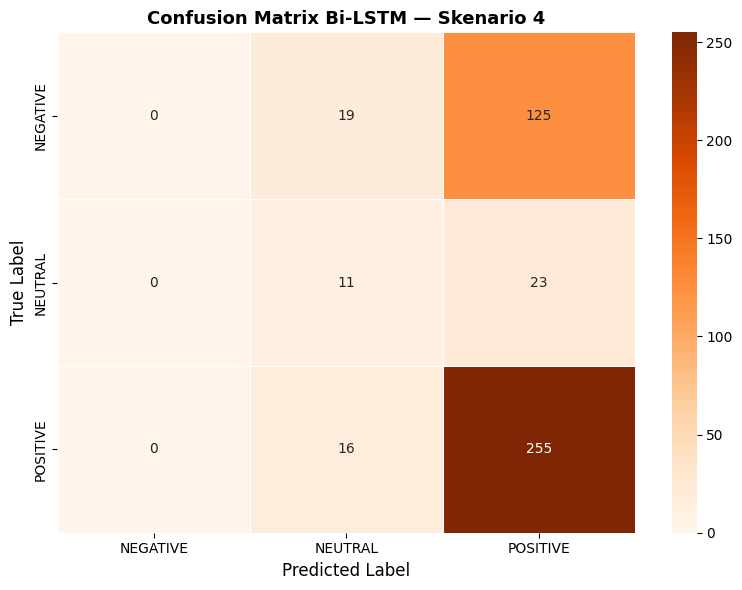

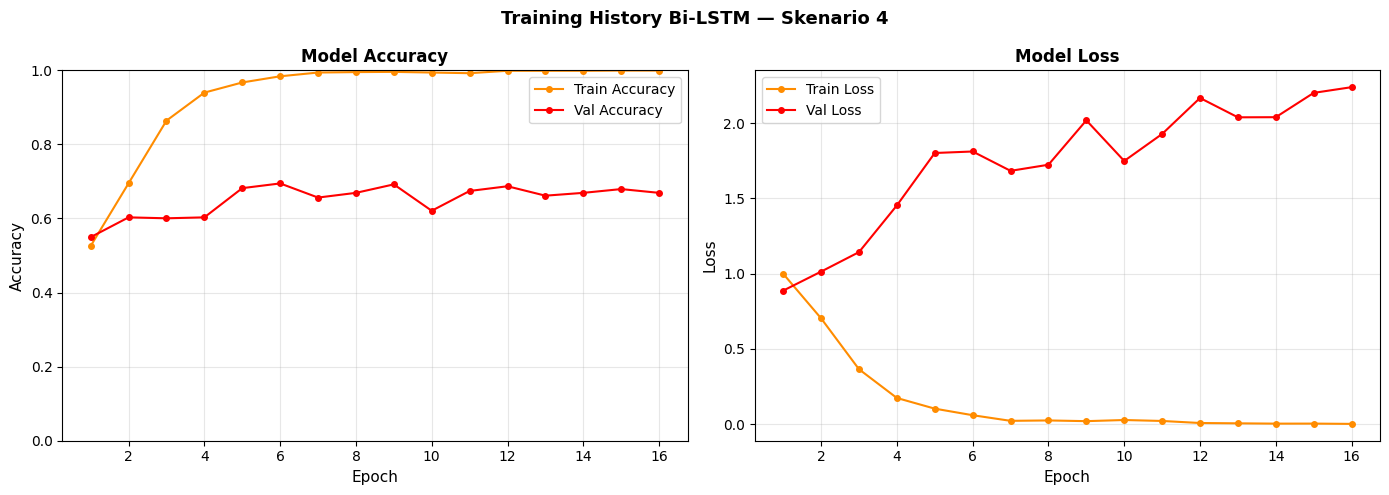


  ✅ Semua output Skenario 4 tersimpan


In [8]:
# ============================================================
# BAGIAN 6 — TRAINING & EVALUASI 4 SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 6: TRAINING & EVALUASI MODEL Bi-LSTM")
print("=" * 70)

all_results   = []
all_histories = []

for skenario in SKENARIO:
    print(f"\n{'='*70}")
    print(f"  {skenario['nama'].upper()}: {skenario['label']}")
    print(f"{'='*70}")

    # -- 6.1 BUILD MODEL --
    print(f"\n  [1/4] Membangun arsitektur model...")
    tf.random.set_seed(RANDOM_STATE)

    model = build_bilstm_model(
        vocab_size    = VOCAB_SIZE,
        embedding_dim = EMBEDDING_DIM,
        max_length    = MAX_LENGTH,
        lstm_units    = skenario['units'],
        num_classes   = NUM_CLASSES,
        dropout_rate  = DROPOUT_RATE,
        learning_rate = LEARNING_RATE
    )

    model.build(input_shape=(None, MAX_LENGTH))
    total_params = model.count_params()

    print(f"  ✅ Model berhasil dibangun")
    print(f"  ✅ Total parameters : {total_params:,}")
    print(f"  ✅ Bi-LSTM output size : {skenario['units']*2} "
          f"(vs LSTM: {skenario['units']})")

    # -- 6.2 CALLBACKS --
    print(f"\n  [2/4] Setup callbacks...")
    model_path = (f'{BILSTM_DIR}/models/'
                  f'bilstm_skenario{skenario["id"]}_best.h5')

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            mode='min',
            min_delta=0.001,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )
    ]
    print(f"  ✅ EarlyStopping (patience=15) aktif")
    print(f"  ✅ ModelCheckpoint → {model_path}")

    # -- 6.3 HITUNG CLASS WEIGHT — IDENTIK dengan LSTM --
    y_tr_classes = np.argmax(y_tr, axis=1)
    weights = compute_class_weight(
        class_weight = 'balanced',
        classes      = np.unique(y_tr_classes),
        y            = y_tr_classes
    )
    CLASS_WEIGHT_DICT = dict(enumerate(weights))

    print(f"\n  Class weights:")
    for cls_idx, w in CLASS_WEIGHT_DICT.items():
        print(f"    Class {cls_idx} ({le.classes_[cls_idx]:<10}): {w:.4f}")

    # -- 6.4 TRAINING --
    print(f"\n  [3/4] Training (max {skenario['epoch']} epoch)...")

    history = model.fit(
        X_tr_resampled, y_tr_resampled,
        epochs=skenario['epoch'],
        batch_size=BATCH_SIZE,
        validation_data=(X_val_resampled, y_val_resampled),
        callbacks=callbacks,
        verbose=1
    )

    actual_epochs    = len(history.history['accuracy'])
    final_train_acc  = history.history['accuracy'][-1]
    final_val_acc    = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss   = history.history['val_loss'][-1]

    print(f"\n  ✅ Training selesai ({actual_epochs} epoch dijalankan)")
    print(f"  ✅ Train Accuracy : {final_train_acc:.4f}")
    print(f"  ✅ Val Accuracy   : {final_val_acc:.4f}")
    print(f"  ✅ Train Loss     : {final_train_loss:.4f}")
    print(f"  ✅ Val Loss       : {final_val_loss:.4f}")

    # -- 6.5 EVALUASI --
    print(f"\n  [4/4] Evaluasi pada data TEST...")

    results, cm, y_pred, y_true = evaluate_model(
        model, X_test, y_test, le,
        skenario['id'], skenario['nama']
    )

    results.update({
        'epoch_digunakan' : actual_epochs,
        'epoch_maksimal'  : skenario['epoch'],
        'units'           : skenario['units'],
        'train_accuracy'  : round(final_train_acc, 4),
        'val_accuracy'    : round(final_val_acc, 4),
        'train_loss'      : round(final_train_loss, 4),
        'val_loss'        : round(final_val_loss, 4),
        'total_params'    : total_params,
    })

    # Tampilkan hasil
    print(f"\n  ┌{'─'*48}┐")
    print(f"  │ HASIL EVALUASI — {skenario['nama']:<28}│")
    print(f"  ├{'─'*48}┤")
    print(f"  │ Accuracy  : {results['accuracy']:.4f} "
          f"({results['accuracy']*100:.2f}%){'':>13}│")
    print(f"  │ Precision : {results['precision']:.4f}{'':>23}│")
    print(f"  │ Recall    : {results['recall']:.4f}{'':>23}│")
    print(f"  │ F1-Score  : {results['f1_score']:.4f}{'':>23}│")
    print(f"  └{'─'*48}┘")

    print(f"\n  Evaluasi per Kelas:")
    print(f"  {'Kelas':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'-'*45}")
    for cls in le.classes_:
        print(f"  {cls:<12} "
              f"{results[f'precision_{cls}']:>10.4f} "
              f"{results[f'recall_{cls}']:>10.4f} "
              f"{results[f'f1_{cls}']:>10.4f}")

    # Simpan plot
    plot_confusion_matrix(
        cm, le, skenario['nama'],
        f'{BILSTM_DIR}/plots/confusion_matrix_s{skenario["id"]}.png'
    )
    plot_training_history(
        history, skenario['nama'],
        f'{BILSTM_DIR}/plots/training_history_s{skenario["id"]}.png'
    )

    all_results.append(results)
    all_histories.append({
        'skenario'    : skenario['nama'],
        'label'       : skenario['label'],
        'accuracy'    : history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'],
        'loss'        : history.history['loss'],
        'val_loss'    : history.history['val_loss'],
    })

    print(f"\n  ✅ Semua output Skenario {skenario['id']} tersimpan")


# BAGIAN 7 — RINGKASAN SEMUA SKENARIO

In [9]:
# ============================================================
# BAGIAN 7 — RINGKASAN SEMUA SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 7: RINGKASAN SEMUA SKENARIO Bi-LSTM")
print("=" * 70)

df_results = pd.DataFrame(all_results)[[
    'skenario', 'epoch_digunakan', 'units',
    'accuracy', 'precision', 'recall', 'f1_score',
    'train_accuracy', 'val_accuracy'
]]
df_results.columns = [
    'Skenario', 'Epoch', 'Units',
    'Test Acc', 'Precision', 'Recall', 'F1-Score',
    'Train Acc', 'Val Acc'
]

print(f"\n{'='*85}")
print(df_results.to_string(index=False))
print(f"{'='*85}")

best_idx = df_results['Test Acc'].idxmax()
best_row = df_results.iloc[best_idx]

print(f"\n✅ SKENARIO TERBAIK : {best_row['Skenario']}")
print(f"   Test Accuracy    : {best_row['Test Acc']:.4f} "
      f"({best_row['Test Acc']*100:.2f}%)")
print(f"   F1-Score         : {best_row['F1-Score']:.4f}")



BAGIAN 7: RINGKASAN SEMUA SKENARIO Bi-LSTM

  Skenario  Epoch  Units  Test Acc  Precision  Recall  F1-Score  Train Acc  Val Acc
Skenario 1     16     64    0.6036     0.3984  0.6036    0.4648     0.9988   0.6514
Skenario 2     16     64    0.6036     0.3643  0.6036    0.4543     1.0000   0.6794
Skenario 3     16     64    0.5947     0.3875  0.5947    0.4662     1.0000   0.6997
Skenario 4     16    128    0.5924     0.4000  0.5924    0.4775     0.9994   0.6692

✅ SKENARIO TERBAIK : Skenario 1
   Test Accuracy    : 0.6036 (60.36%)
   F1-Score         : 0.4648


# BAGIAN 8 — VISUALISASI PERBANDINGAN ANTAR SKENARIO


BAGIAN 8: VISUALISASI PERBANDINGAN ANTAR SKENARIO


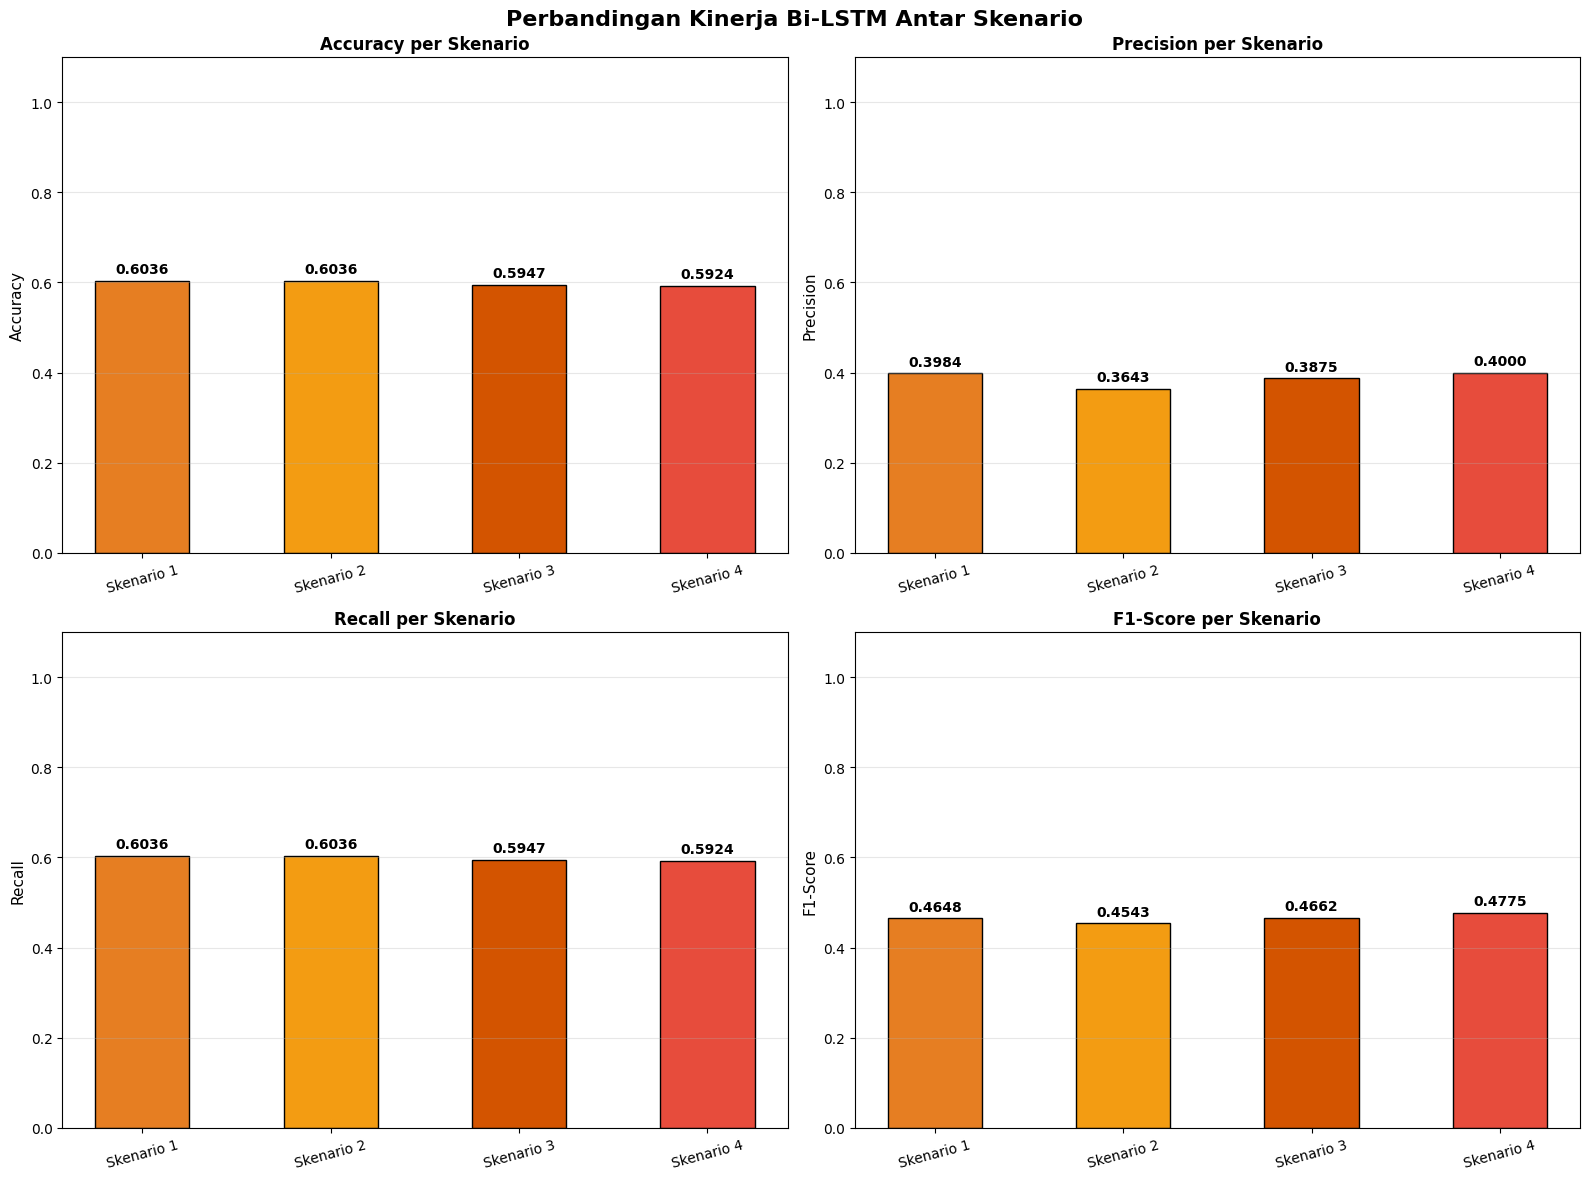

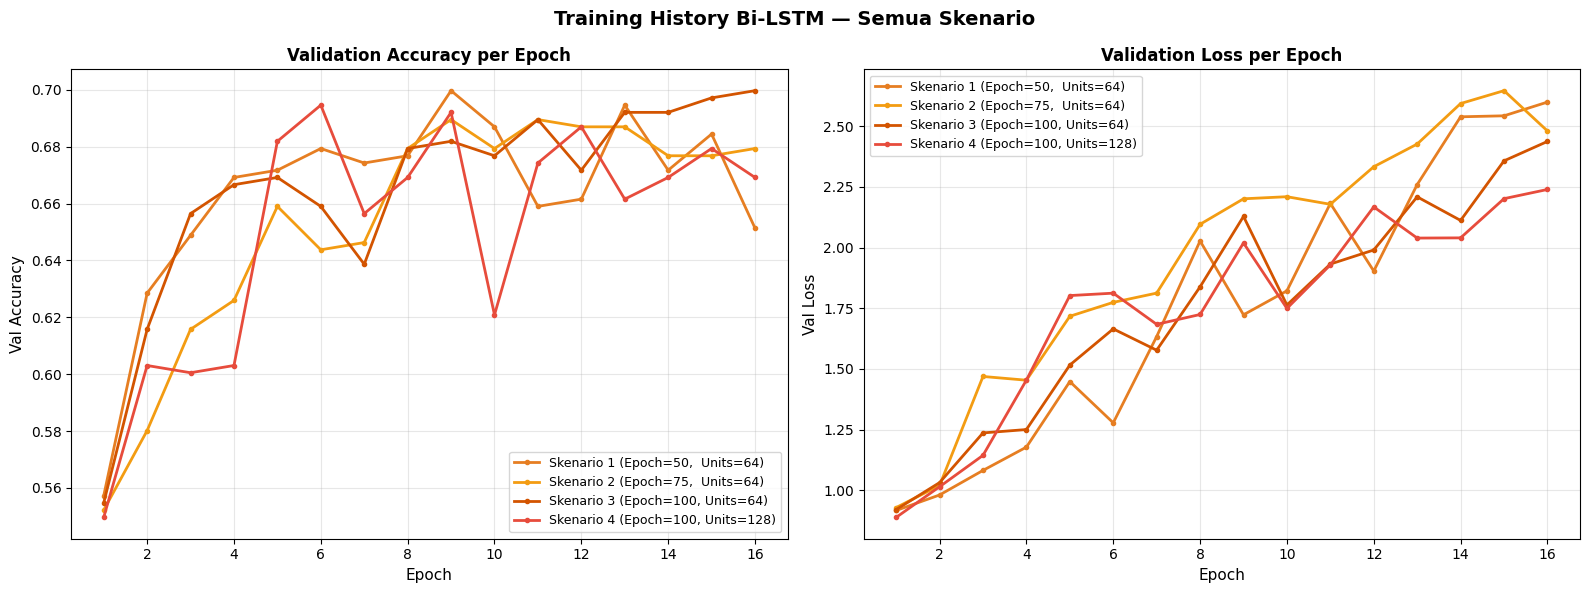

✅ Semua visualisasi tersimpan


In [10]:
# ============================================================
# BAGIAN 8 — VISUALISASI PERBANDINGAN ANTAR SKENARIO
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 8: VISUALISASI PERBANDINGAN ANTAR SKENARIO")
print("=" * 70)

colors = ['#e67e22', '#f39c12', '#d35400', '#e74c3c']

# Plot 1: Bar chart 4 metrik
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perbandingan Kinerja Bi-LSTM Antar Skenario',
             fontsize=16, fontweight='bold')

skenario_labels = [r['skenario'] for r in all_results]
metrics_list    = ['accuracy', 'precision', 'recall', 'f1_score']
metric_titles   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics_list, metric_titles)):
    ax     = axes[idx // 2][idx % 2]
    values = [r[metric] for r in all_results]
    bars   = ax.bar(skenario_labels, values,
                    color=colors, edgecolor='black', width=0.5)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} per Skenario', fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(f'{BILSTM_DIR}/plots/comparison_all_scenarios.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Training history semua skenario
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History Bi-LSTM — Semua Skenario',
             fontsize=14, fontweight='bold')

for idx, hist_data in enumerate(all_histories):
    epochs_range = range(1, len(hist_data['accuracy']) + 1)
    axes[0].plot(epochs_range, hist_data['val_accuracy'],
                 '-o', color=colors[idx],
                 label=f"{hist_data['skenario']} ({hist_data['label']})",
                 markersize=3, linewidth=2)
    axes[1].plot(epochs_range, hist_data['val_loss'],
                 '-o', color=colors[idx],
                 label=f"{hist_data['skenario']} ({hist_data['label']})",
                 markersize=3, linewidth=2)

for ax, ylabel, title in zip(
    axes,
    ['Val Accuracy', 'Val Loss'],
    ['Validation Accuracy per Epoch', 'Validation Loss per Epoch']
):
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BILSTM_DIR}/plots/training_history_all.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Semua visualisasi tersimpan")


# BAGIAN 9 — SIMPAN HASIL

In [11]:
# ============================================================
# BAGIAN 9 — SIMPAN HASIL
# ============================================================
print("\n" + "=" * 70)
print("BAGIAN 9: SIMPAN HASIL")
print("=" * 70)

# Simpan CSV hasil
csv_path = f'{BASE_DIR}/data/results/results_bilstm.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
pd.DataFrame(all_results).to_csv(csv_path, index=False)
print(f"✅ results_bilstm.csv tersimpan")

# Simpan summary JSON
summary = {
    'model'           : 'Bi-LSTM',
    'total_skenario'  : len(SKENARIO),
    'parameter_model' : {
        'VOCAB_SIZE'    : VOCAB_SIZE,
        'EMBEDDING_DIM' : EMBEDDING_DIM,
        'MAX_LENGTH'    : MAX_LENGTH,
        'NUM_CLASSES'   : NUM_CLASSES,
        'BATCH_SIZE'    : BATCH_SIZE,
        'LEARNING_RATE' : LEARNING_RATE,
        'DROPOUT_RATE'  : DROPOUT_RATE,
        'RANDOM_STATE'  : RANDOM_STATE,
    },
    'hasil_per_skenario' : all_results,
    'skenario_terbaik'   : all_results[best_idx],
}

with open(f'{BILSTM_DIR}/summary_bilstm.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✅ summary_bilstm.json tersimpan")



BAGIAN 9: SIMPAN HASIL
✅ results_bilstm.csv tersimpan
✅ summary_bilstm.json tersimpan


# BAGIAN 10 — SUMMARY FINAL

In [12]:
# ============================================================
# BAGIAN 10 — SUMMARY FINAL
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY FINAL — Bi-LSTM")
print("=" * 70)

print(f"\nData yang digunakan:")
print(f"  Total sampel   : {len(X)}")
print(f"  Train set      : {len(X_train)}")
print(f"  Test set       : {len(X_test)}")

print(f"\nHasil per skenario:")
print(f"{'Skenario':<15} {'Epoch':>7} {'Units':>7} "
      f"{'Accuracy':>10} {'F1-Score':>10}")
print(f"{'─'*52}")

for r in all_results:
    print(f"  {r['skenario']:<13} {r['epoch_digunakan']:>7} "
          f"{r['units']:>7} {r['accuracy']:>10.4f} {r['f1_score']:>10.4f}")

print(f"\n✅ Skenario terbaik: {best_row['Skenario']}")
print(f"   Accuracy        : {best_row['Test Acc']:.4f}")
print(f"   F1-Score        : {best_row['F1-Score']:.4f}")

print("\n" + "=" * 70)
print("✅ FILE 4: TRAINING MODEL Bi-LSTM SELESAI!")
print("=" * 70)
print("\nLanjutkan ke:")
print("  → 5_Comparison_Analysis.ipynb")
print(f"\nFile yang dibutuhkan:")
print(f"  → {BASE_DIR}/data/results/results_lstm.csv")
print(f"  → {BASE_DIR}/data/results/results_bilstm.csv")



SUMMARY FINAL — Bi-LSTM

Data yang digunakan:
  Total sampel   : 2245
  Train set      : 1796
  Test set       : 449

Hasil per skenario:
Skenario          Epoch   Units   Accuracy   F1-Score
────────────────────────────────────────────────────
  Skenario 1         16      64     0.6036     0.4648
  Skenario 2         16      64     0.6036     0.4543
  Skenario 3         16      64     0.5947     0.4662
  Skenario 4         16     128     0.5924     0.4775

✅ Skenario terbaik: Skenario 1
   Accuracy        : 0.6036
   F1-Score        : 0.4648

✅ FILE 4: TRAINING MODEL Bi-LSTM SELESAI!

Lanjutkan ke:
  → 5_Comparison_Analysis.ipynb

File yang dibutuhkan:
  → /content/drive/MyDrive/skripsi_mbg/data/results/results_lstm.csv
  → /content/drive/MyDrive/skripsi_mbg/data/results/results_bilstm.csv
